**14/08/2026** -- Figure 2: Fire PM2.5 concentrations across Africa

Data for 2000-2022.

In [21]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [22]:
library(dplyr)
library(readr)
library(sf)
library(ggplot2)
library(cowplot)

In [23]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/plotting.R"))    # plot_map() wrapper of ggplot() + geom_sf(), and density_plot()

In [24]:
# Functions for custom themes of map and density plots
maps_theme <- function() {
    theme(
        legend.position         = "bottom",
        legend.title            = element_text(size = 14, face = "plain"),
        legend.key.height       = NULL,
        legend.key.width        = unit(2, "cm"),
        legend.title.position   = "top",
        axis.text.x             = element_text(color = "black", size = 10)
    )
}

density_theme <- function() {
    theme_minimal() +
    theme(
        axis.title.y    = element_blank(),
        axis.text.y     = element_blank(),
        axis.ticks.y    = element_blank(),
        axis.title.x    = element_blank(),
        panel.grid      = element_blank(),
        axis.line.x     = element_line(color = "black"),
        axis.ticks.x    = element_line(color = "black"),
        axis.text.x     = element_text(color = "black", size = 10),
        panel.background    = element_rect(fill = NA, color = NA),
        plot.background     = element_rect(fill = NA, color = NA)
    )
}

In [25]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_2000_2023.csv")
NAT_BOUNDS_PATH     <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "WB_countries_Admin0_10m")
western_sahara_path <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "western_sahara/gadm41_ESH_0.shp")

In [6]:
df <- read_csv(DATA_PATH)

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [26]:
nat_bounds <- sf::read_sf(NAT_BOUNDS_PATH) |> 
    filter(CONTINENT == "Africa")

In [27]:
esh_bounds <- sf::read_sf(western_sahara_path)

In [28]:
# Get average values over 2000-2022
df_avg <- df |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |> 
    summarise(
        geometry    = first(geometry),
        fire_PM25   = mean(fire_PM25_hu, na.rm = TRUE),
        .groups     = "drop"
    )

In [1]:
# Convert to sf
sf <- df_avg |> 
    mutate(geometry = sf::st_as_sfc(geometry)) |> 
    sf::st_as_sf(crs = 4326)

In [30]:
# Make map
fire_PM25_map <- plot_map(
    data = sf, 
    color = "fire_PM25", 
    fill = "fire_PM25", 
    name = "Fire PM₂.₅ (μg/m³)", 
    palette = "YlOrRd", 
    ticks_color = "black",
    nat_bounds_sf = nat_bounds, 
    grid_off = FALSE
) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40") + # Western Sahara #nolint
    maps_theme()

In [35]:
# Make density plot
dens_fire_PM25 <- density_plot(sf, 
                               variable = "fire_PM25",
                               from = 0) + 
    scale_x_continuous(breaks = seq(5, 20, 5), expand = c(0, 0)) +  # set breaks manually and remove x-axis padding # 
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +     # small top padding
    density_theme()

In [36]:
options(repr.plot.height = 8, repr.plot.width = 8)

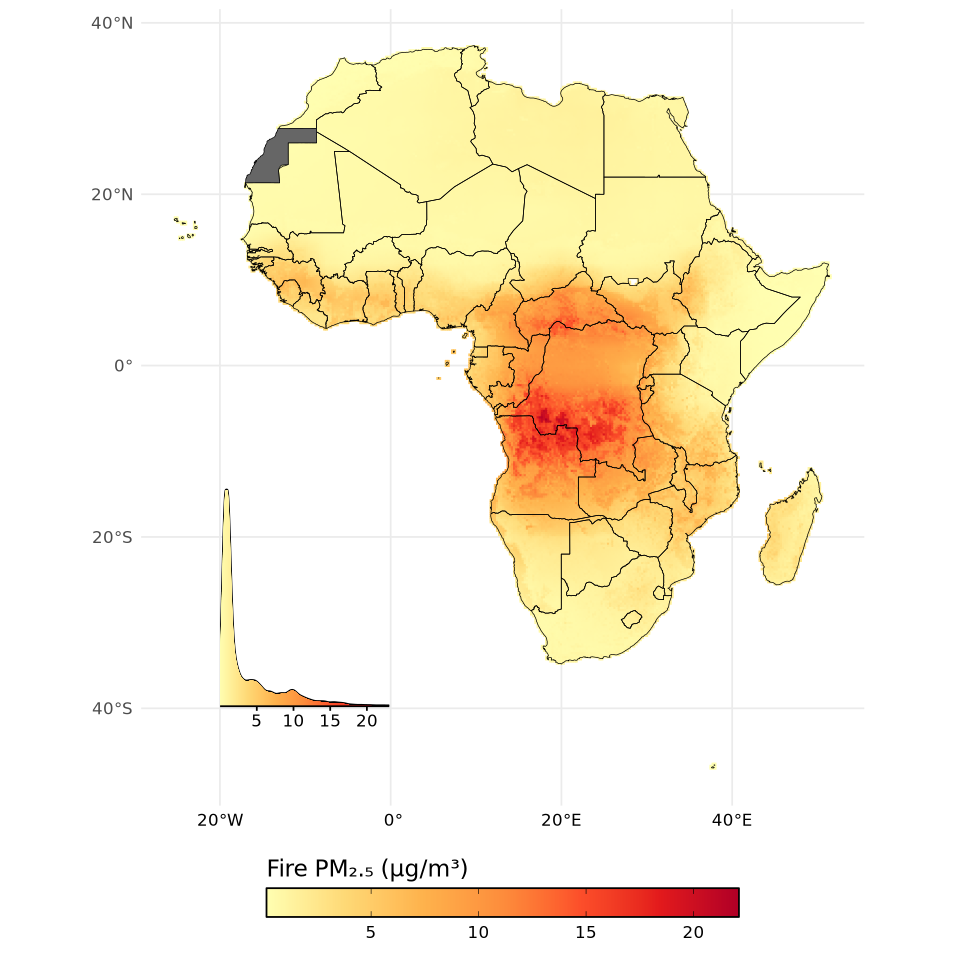

: 

In [ ]:
suppressWarnings({
    fire_PM25_with_density <- ggdraw() +
        draw_plot(fire_PM25_map, 0, 0, 1, 1) +
        # position the density kernels
        draw_plot(dens_fire_PM25, 
                  x = 0.215, 
                  y = 0.23,
                  width = 0.2, 
                  height = 0.28)
})
fire_PM25_with_density

In [20]:
ggsave(
    filename = file.path(root, "paper_results/figures/fig_2.png"),
    dpi = 450,
    width = 8,
    height = 8,
    bg = "white"
)